# Notebook for rink maps

## Housekeeping

### Import dependencies

In [1]:
import pandas as pd
import numpy as np

from chickenstats.chicken_nhl import Season, Scraper
from chickenstats.chicken_nhl.helpers import norm_coords

from hockey_rink import NHLRink
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from pathlib import Path

### Pandas options

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### Environment variables

In [3]:
env_path = Path("../../../chickenstats-xg/.env")
load_dotenv(env_path)

True

## Scrape data

### Schedule and game IDs

In [4]:
season = Season(2023)

In [5]:
schedule = season.schedule("NSH")

Output()

In [6]:
game_ids = schedule.game_id.tolist()  # [:10]
game_id = game_ids[0]

### Play-by-play

In [7]:
scraper = Scraper(game_ids)

In [8]:
pbp = scraper.play_by_play

Output()

In [9]:
scraper.prep_stats(level="season")
stats = scraper.stats

In [10]:
scraper.prep_lines(level="season")
lines = scraper.lines

In [11]:
scraper.prep_team_stats(level="season")
team_stats = scraper.team_stats

## Rink plots

### Practice drawing

In [12]:
rink = NHLRink(rotation=90)

<Axes: >

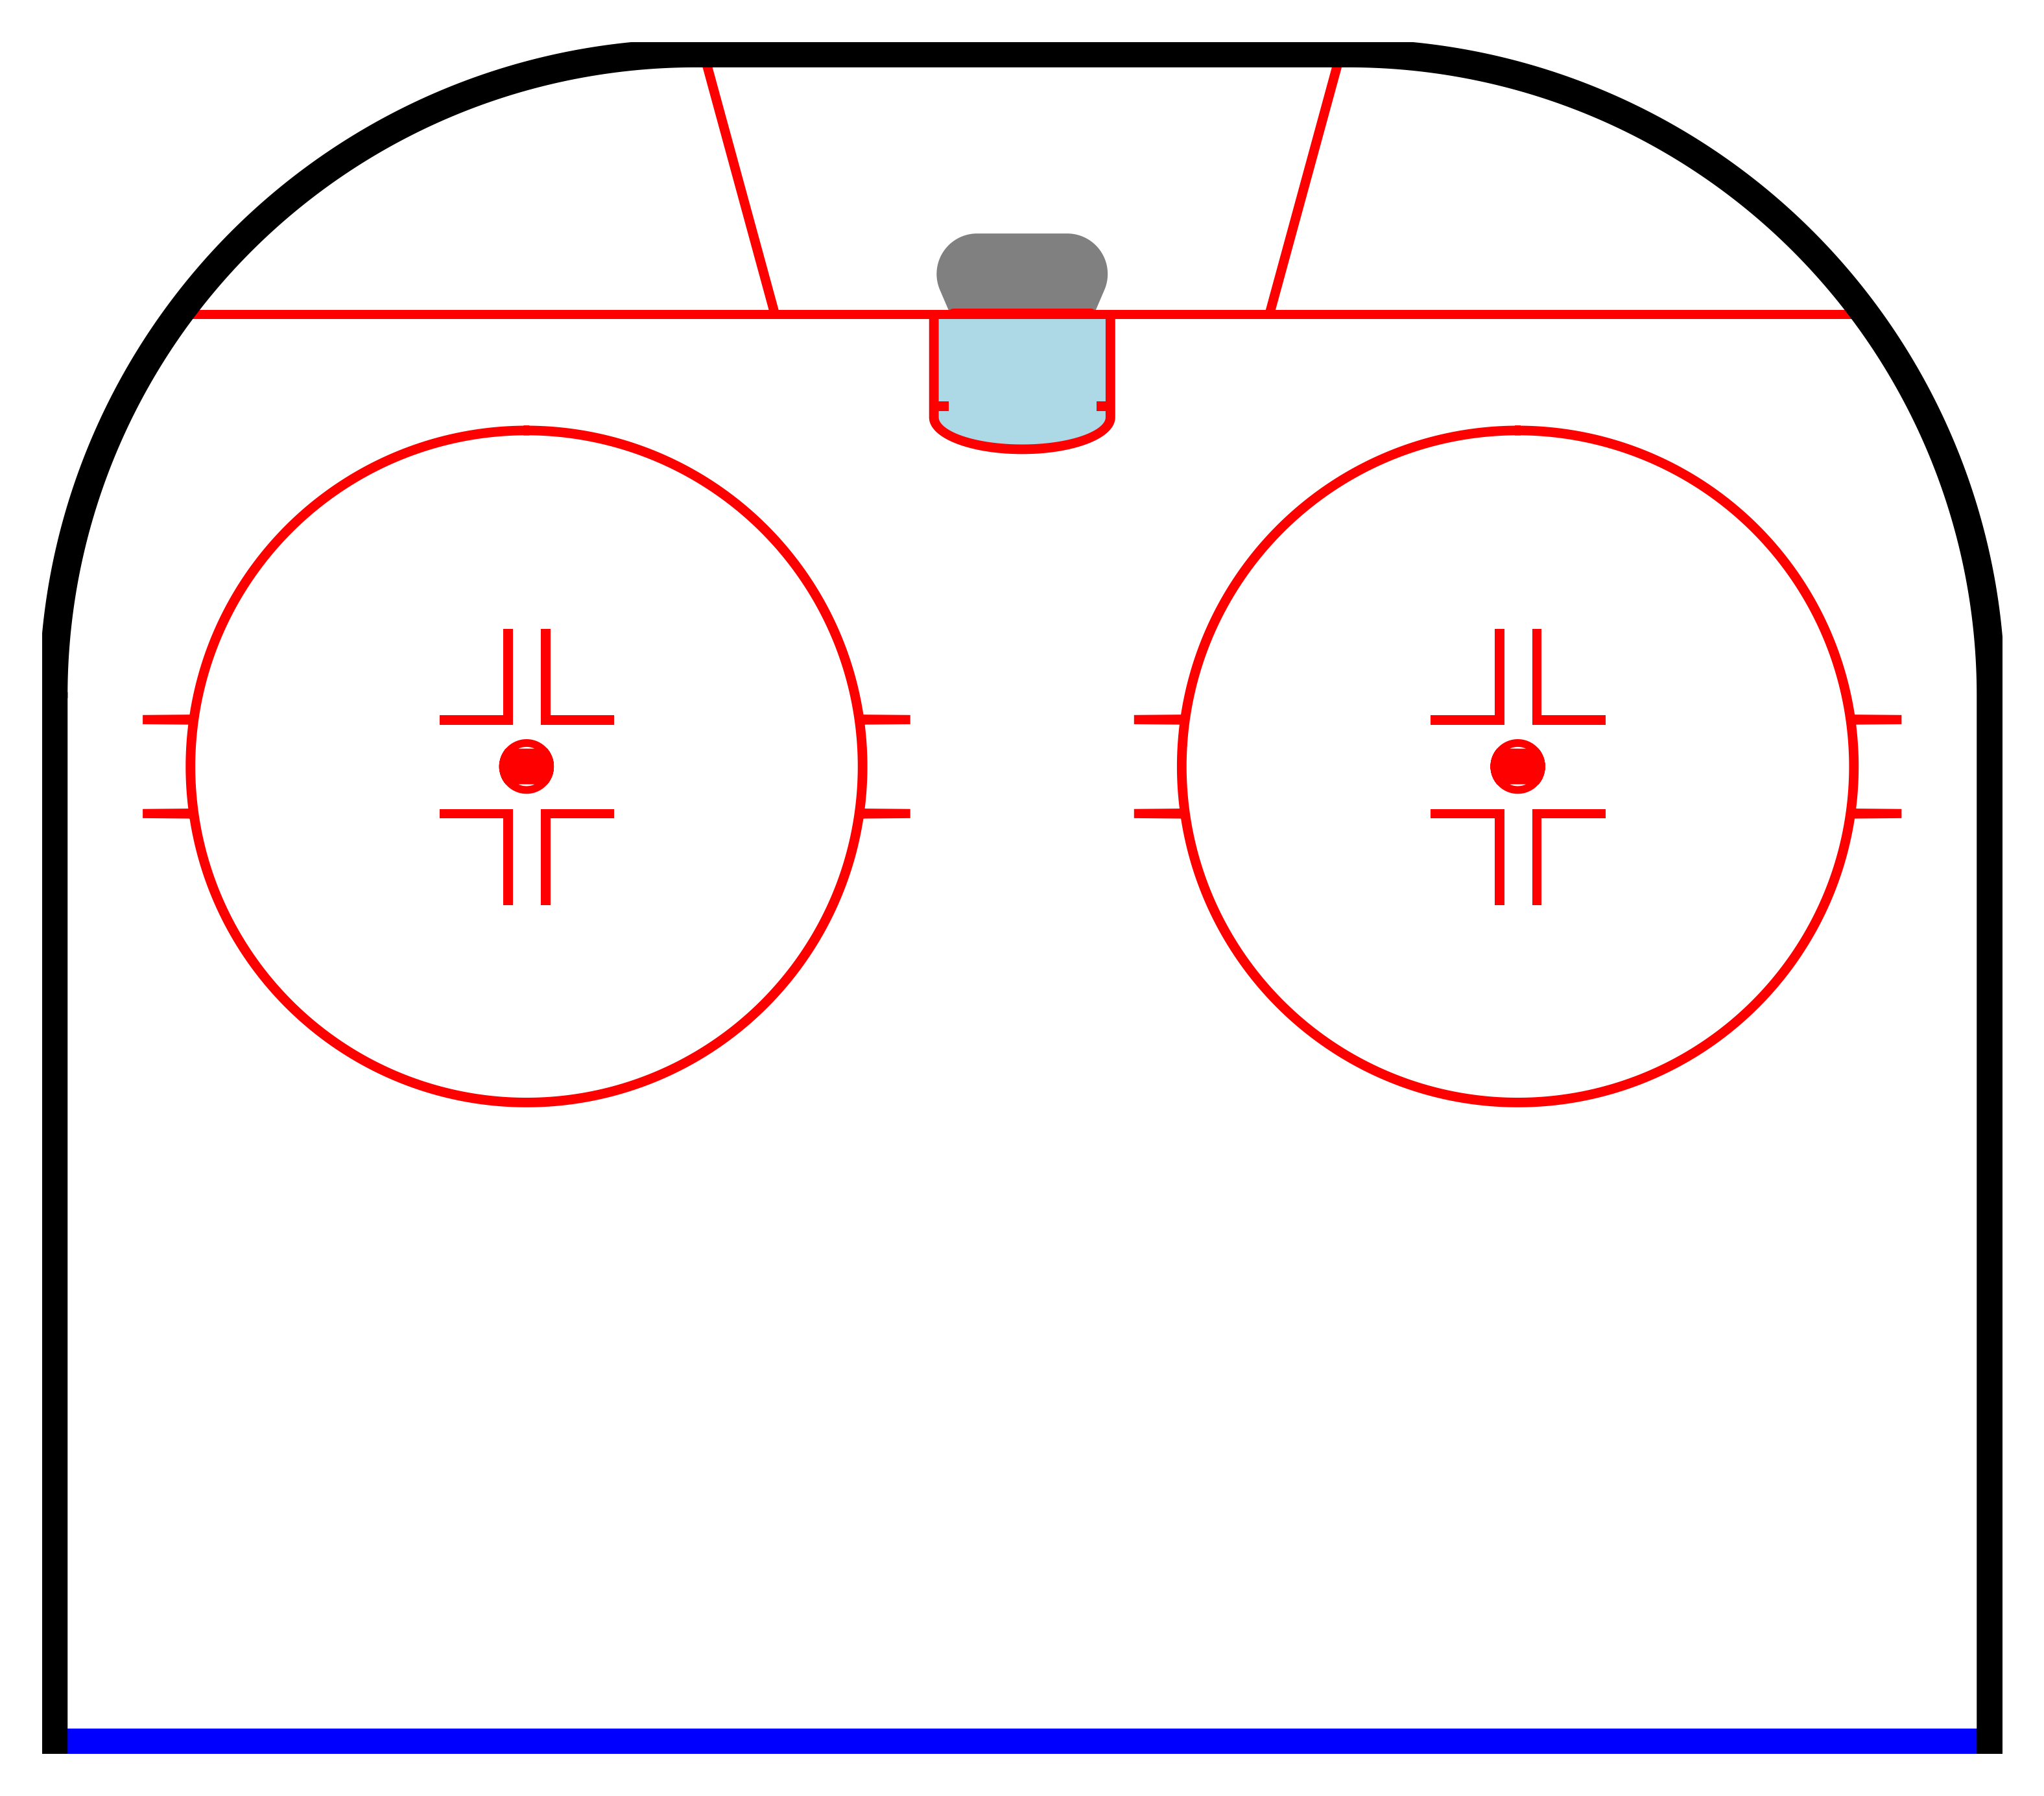

In [13]:
fig, ax = plt.subplots(dpi=650, figsize=(6, 6))

rink.draw(display_range="ozone", ax=ax)

In [21]:
top_shooters = stats.sort_values(by="ixg", ascending=False).head(6).player.tolist()

In [24]:
shot_events = ["GOAL", "SHOT", "MISS"]
strengths = ["5v5"]

conds = np.logical_and(pbp.event.isin(shot_events), pbp.strength_state.isin(strengths))

shots = pbp.loc[conds].reset_index(drop=True)
shots = norm_coords(shots, "NSH")

<Axes: xlabel='norm_coords_x', ylabel='norm_coords_y'>

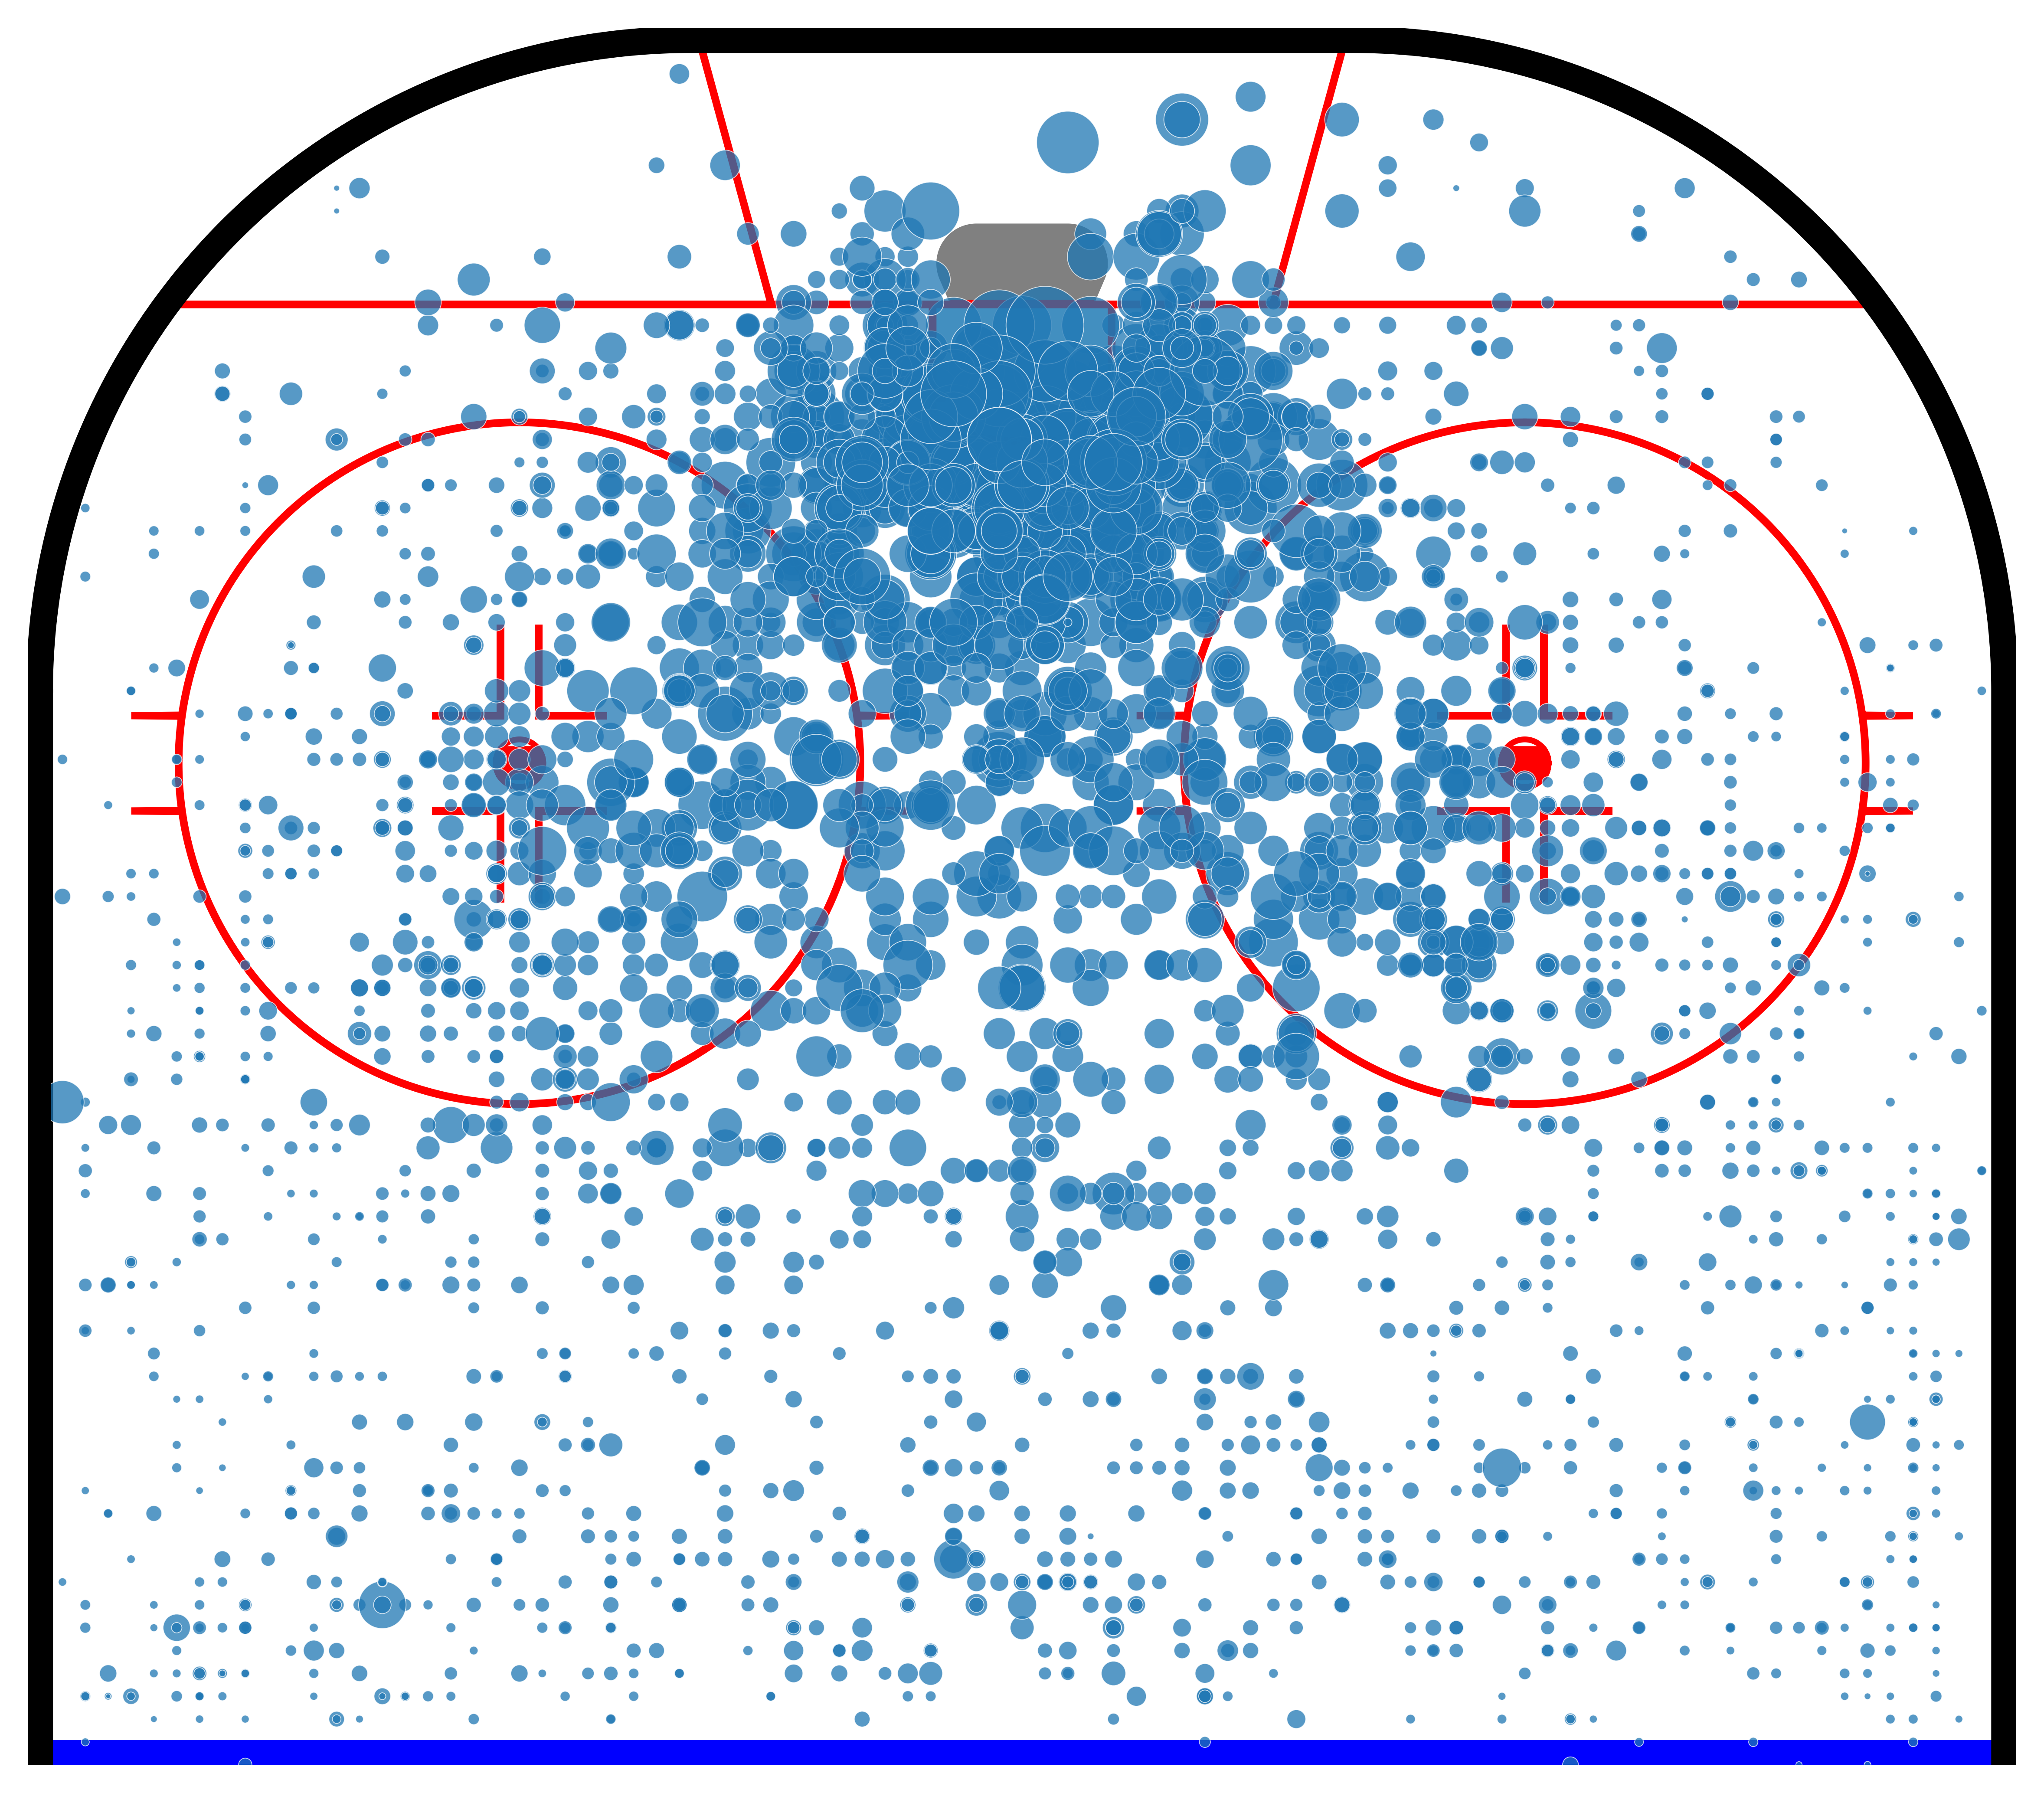

In [19]:
rink = NHLRink(rotation=90)

fig, axes = plt.subplots(dpi=650, figsize=(18, 8))

rink.draw(
    ax=ax,
    display_range="ozone",
)

data = norm_coords(shots, "NSH")

data = data.loc[data.event_team == "NSH"]

rink.plot_fn(
    sns.scatterplot,
    data=data,
    x="norm_coords_x",
    y="norm_coords_y",
    s=data.pred_goal * 750,
    zorder=100,
    alpha=0.75,
    ax=ax,
)
# rink.plot_fn(sns.scatterplot, data=data, x="coords_x", y="coords_y", sizes=100, ax=ax)

In [17]:
shots.head(3)

,id,season,session,game_id,game_date,event_idx,period,period_seconds,game_seconds,strength_state,event_team,opp_team,event,description,zone,coords_x,coords_y,danger,high_danger,player_1,player_1_eh_id,player_1_eh_id_api,player_1_api_id,player_1_position,player_1_type,player_2,player_2_eh_id,player_2_eh_id_api,player_2_api_id,player_2_position,player_2_type,player_3,player_3_eh_id,player_3_eh_id_api,player_3_api_id,player_3_position,player_3_type,score_state,score_diff,forwards_percent,opp_forwards_percent,shot_type,event_length,event_distance,pbp_distance,event_angle,penalty,penalty_length,home_score,home_score_diff,away_score,away_score_diff,is_home,is_away,home_team,away_team,home_skaters,away_skaters,home_on,home_on_eh_id,home_on_api_id,home_on_positions,away_on,away_on_eh_id,away_on_api_id,away_on_positions,event_team_skaters,teammates,teammates_eh_id,teammates_api_id,teammates_positions,own_goalie,own_goalie_eh_id,own_goalie_api_id,forwards,forwards_eh_id,forwards_api_id,forwards_count,defense,defense_eh_id,defense_api_id,defense_count,opp_strength_state,opp_score_state,opp_score_diff,opp_team_skaters,opp_team_on,opp_team_on_eh_id,opp_team_on_api_id,opp_team_on_positions,opp_goalie,opp_goalie_eh_id,opp_goalie_api_id,opp_forwards,opp_forwards_eh_id,opp_forwards_api_id,opp_forwards_count,opp_defense,opp_defense_eh_id,opp_defense_api_id,opp_defense_count,home_forwards,home_forwards_eh_id,home_forwards_api_id,home_forwards_count,home_forwards_percent,home_defense,home_defense_eh_id,home_defense_api_id,home_defense_count,home_goalie,home_goalie_eh_id,home_goalie_api_id,away_forwards,away_forwards_eh_id,away_forwards_api_id,away_forwards_count,away_forwards_percent,away_defense,away_defense_eh_id,away_defense_api_id,away_defense_count,away_goalie,away_goalie_eh_id,away_goalie_api_id,change_on_count,change_off_count,change_on,change_on_eh_id,change_on_api_id,change_on_positions,change_off,change_off_eh_id,change_off_api_id,change_off_positions,change_on_forwards_count,change_off_forwards_count,change_on_forwards,change_on_forwards_eh_id,change_on_forwards_api_id,change_off_forwards,change_off_forwards_eh_id,change_off_forwards_api_id,change_on_defense_count,change_off_defense_count,change_on_defense,change_on_defense_eh_id,change_on_defense_api_id,change_off_defense,change_off_defense_eh_id,change_off_defense_api_id,change_on_goalie_count,change_off_goalie_count,change_on_goalie,change_on_goalie_eh_id,change_on_goalie_api_id,change_off_goalie,change_off_goalie_eh_id,change_off_goalie_api_id,goal,hd_goal,shot,hd_shot,miss,hd_miss,fenwick,hd_fenwick,corsi,block,teammate_block,hit,give,take,fac,penl,change,stop,chl,ozf,nzf,dzf,ozc,nzc,dzc,otf,pen0,pen2,pen4,pen5,pen10,pred_goal,norm_coords_x,norm_coords_y
0,20230200010020,20232024,R,2023020001,2023-10-10,20,1,61,61,5v5,TBL,NSH,SHOT,"TBL ONGOAL - #43 RADDYSH, WRIST , OFF. ZONE, 3...",OFF,59.0,-26.0,0.0,0.0,DARREN RADDYSH,DARREN.RADDYSH,DARREN.RADDYSH,8478178,D,SHOOTER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0v0,0,0.6,0.6,WRIST,9,39.698866,39.0,40.914383,NaN,NaN,0,0,0,0,1,0,TBL,NSH,5,5,"BRAYDEN POINT, NIKITA KUCHEROV, STEVEN STAMKOS...","BRAYDEN.POINT, NIKITA.KUCHEROV, STEVEN.STAMKOS...","8478010, 8476453, 8474564, 8478178, 8479410","C, R, C, D, D","COLTON SISSONS, YAKOV TRENIN, COLE SMITH, LUKE...","COLTON.SISSONS, YAKOV.TRENIN, COLE.SMITH, LUKE...","8476925, 8478508, 8482062, 8474568, 8474600","C, C, L, D, D",5,"BRAYDEN POINT, NIKITA KUCHEROV, STEVEN STAMKOS...","BRAYDEN.POINT, NIKITA.KUCHEROV, STEVEN.STAMKOS...","8478010, 8476453, 8474564, 8478178, 8479410","C, R, C, D, D",JONAS JOHANSSON,JONAS.JOHANSSON,8477992,"BRAYDEN POINT, NIKITA KUCHEROV, STEVEN STAMKOS","BRAYDEN.POINT, NIKITA.KUCHEROV, STEVEN.STAMKOS","8478010, 8476453, 8474564",3,"DARREN RADDYSH, MIKHAIL SERGACHEV","DARREN.RADDYSH, MIKHAIL.SERGACHEV","8478178, 8479410",2,5v5,0v0,0,5,"COLTON SISSONS, YAKOV TRENIN, COLE SMITH, LUKE...","COLTON.SISSONS, YAKOV.TRENIN, COLE.SMITH, LUKE...","8476925, 8478508, 8482062, 84

In [18]:
shots.pred_goal.max()

np.float64(0.5685808658599854)